## 1. Import Libraries

In [56]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score



## 2. Load Dataset

In [57]:
df=pd.read_csv(r"D:\INSTANT\Git Hub\Heart Failure\heart.csv")

## 3. Initial Data Exploration

In [58]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [60]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## 4. Categorical Analysis (Groupby)

In [63]:
df.groupby("Sex")["HeartDisease"].value_counts()

Sex  HeartDisease
F    0               143
     1                50
M    1               458
     0               267
Name: count, dtype: int64

In [64]:
df.groupby("ChestPainType")["HeartDisease"].value_counts()

ChestPainType  HeartDisease
ASY            1               392
               0               104
ATA            0               149
               1                24
NAP            0               131
               1                72
TA             0                26
               1                20
Name: count, dtype: int64

In [65]:
df.groupby("RestingECG")["HeartDisease"].value_counts()

RestingECG  HeartDisease
LVH         1               106
            0                82
Normal      1               285
            0               267
ST          1               117
            0                61
Name: count, dtype: int64

In [66]:
df.groupby("ExerciseAngina")["HeartDisease"].value_counts()

ExerciseAngina  HeartDisease
N               0               355
                1               192
Y               1               316
                0                55
Name: count, dtype: int64

In [67]:
df.groupby("FastingBS")["HeartDisease"].value_counts()

FastingBS  HeartDisease
0          0               366
           1               338
1          1               170
           0                44
Name: count, dtype: int64

In [68]:
df.groupby("Sex")["ChestPainType"].value_counts()

Sex  ChestPainType
F    ASY               70
     ATA               60
     NAP               53
     TA                10
M    ASY              426
     NAP              150
     ATA              113
     TA                36
Name: count, dtype: int64

In [69]:
df.groupby("Sex")["RestingECG"].value_counts()

Sex  RestingECG
F    Normal        118
     LVH            47
     ST             28
M    Normal        434
     ST            150
     LVH           141
Name: count, dtype: int64

In [70]:
df.groupby("Sex")["ST_Slope"].value_counts()

Sex  ST_Slope
F    Up          111
     Flat         75
     Down          7
M    Flat        385
     Up          284
     Down         56
Name: count, dtype: int64

## 5. Correlation & Mean Comparisons

In [71]:
df.loc[:,["Age","RestingBP"]].corr()

,Age,RestingBP
Age,1.000000,0.254399
RestingBP,0.254399,1.000000


In [72]:
df.loc[:,["Age","Cholesterol"]].corr()

,Age,Cholesterol
Age,1.000000,-0.095282
Cholesterol,-0.095282,1.000000


In [73]:
df.groupby("HeartDisease")["Age"].mean()

HeartDisease
0    50.551220
1    55.899606
Name: Age, dtype: float64

In [74]:
df.groupby("HeartDisease")["RestingBP"].mean()

HeartDisease
0    130.180488
1    134.185039
Name: RestingBP, dtype: float64

In [75]:
df.groupby("HeartDisease")["Cholesterol"].mean()

HeartDisease
0    227.121951
1    175.940945
Name: Cholesterol, dtype: float64

In [76]:
df.groupby("HeartDisease")["MaxHR"].mean()

HeartDisease
0    148.151220
1    127.655512
Name: MaxHR, dtype: float64

In [77]:
df.groupby("HeartDisease")["Oldpeak"].mean()

HeartDisease
0    0.408049
1    1.274213
Name: Oldpeak, dtype: float64

## 6. Data Visualization

In [78]:
COLOR_NO_DISEASE = "#2E86AB"  
COLOR_DISEASE    = "#E76F51"   
palette = [COLOR_NO_DISEASE, COLOR_DISEASE]

sns.set_theme(style="whitegrid")

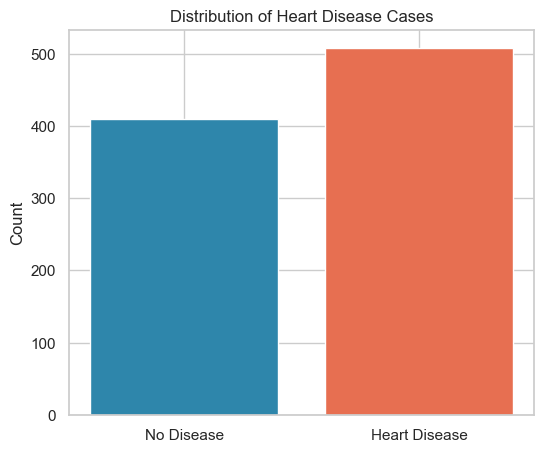

In [79]:
counts = df['HeartDisease'].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(['No Disease', 'Heart Disease'], counts, color=palette)
plt.title('Distribution of Heart Disease Cases')
plt.ylabel('Count')
plt.show()

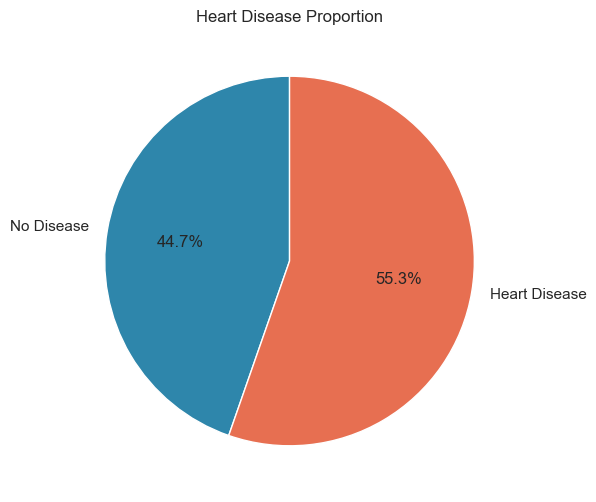

In [80]:
plt.figure(figsize=(13, 6))
plt.pie(counts, labels=['No Disease', 'Heart Disease'], autopct='%1.1f%%', startangle=90, colors=palette)
plt.title('Heart Disease Proportion')
plt.show()

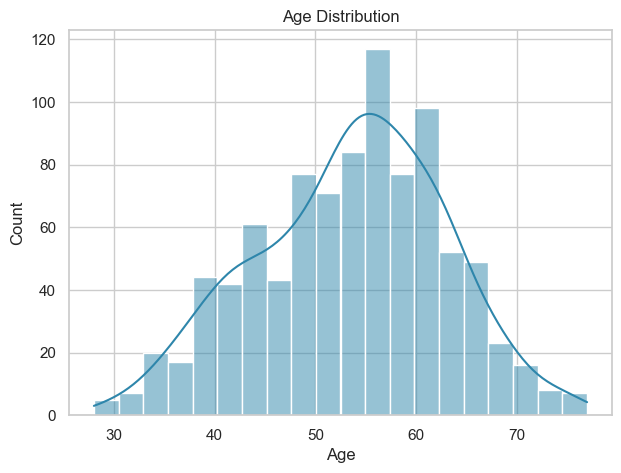

In [81]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Age'], kde=True, color=palette[0], bins=20)
plt.title('Age Distribution')
plt.show()

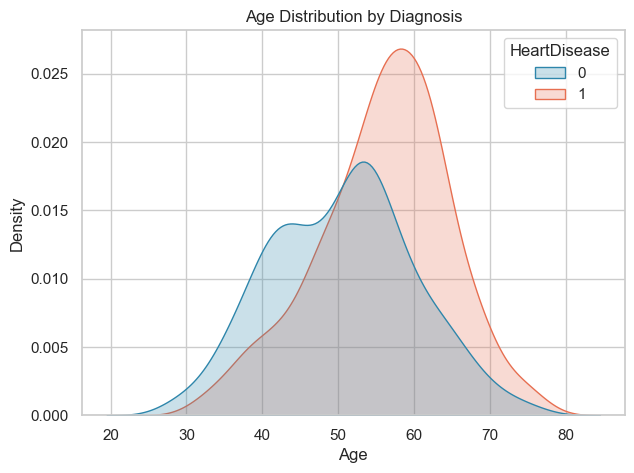

In [82]:
plt.figure(figsize=(7, 5))
sns.kdeplot(data=df, x='Age', hue='HeartDisease', fill=True, palette=palette)
plt.title('Age Distribution by Diagnosis')
plt.show()

C:\Users\Eng\AppData\Local\Temp\ipykernel_14412\603365126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette=palette)


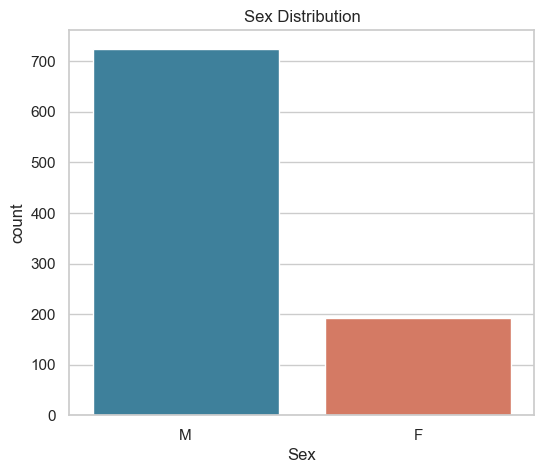

In [83]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Sex', palette=palette)
plt.title('Sex Distribution')
plt.show()

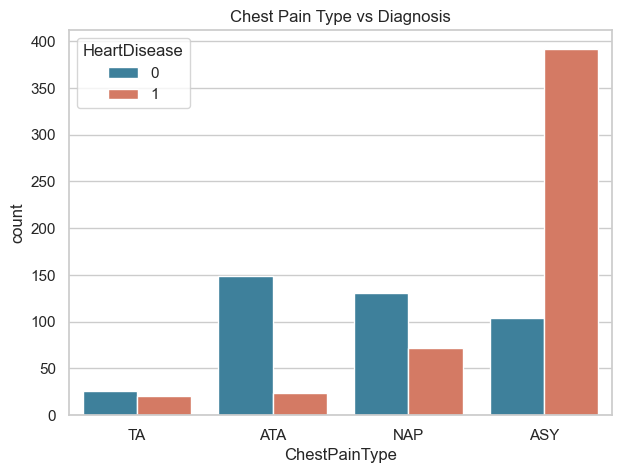

In [84]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', order=['TA','ATA','NAP','ASY'], palette=palette)
plt.title('Chest Pain Type vs Diagnosis')
plt.show()

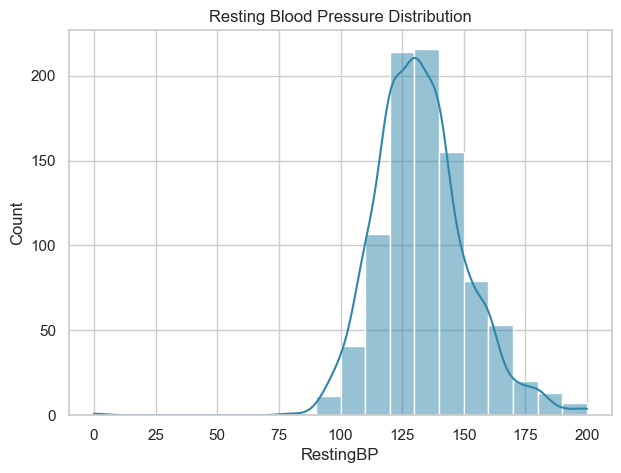

In [85]:
plt.figure(figsize=(7, 5))
sns.histplot(df['RestingBP'], kde=True, color=palette[0], bins=20)
plt.title('Resting Blood Pressure Distribution')
plt.show()

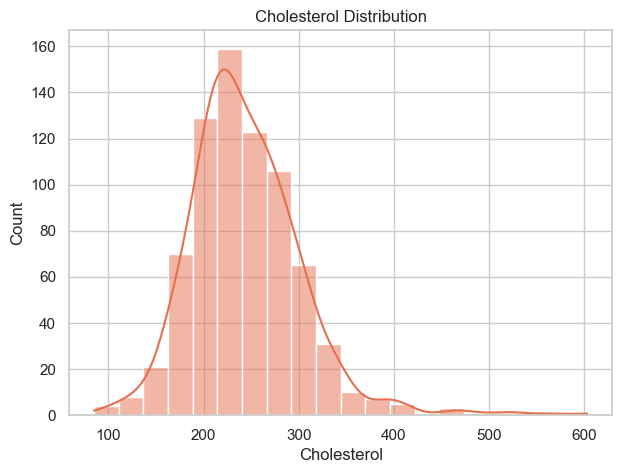

In [86]:
plt.figure(figsize=(7, 5))
sns.histplot(df[df['Cholesterol'] > 0]['Cholesterol'], kde=True, color=palette[1], bins=20)
plt.title('Cholesterol Distribution')
plt.show()

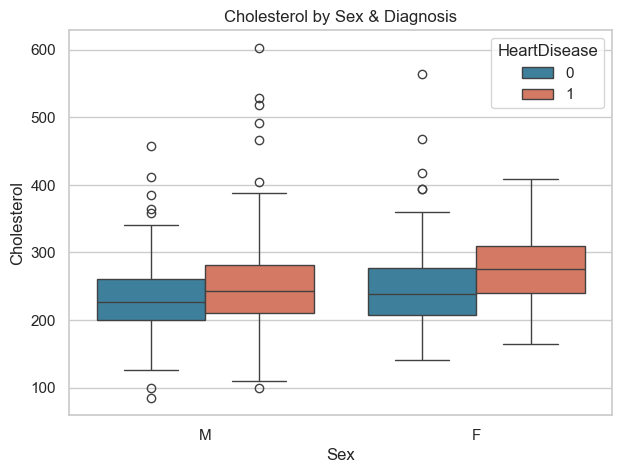

In [87]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df[df['Cholesterol'] > 0], x='Sex', y='Cholesterol', hue='HeartDisease', palette=palette)
plt.title('Cholesterol by Sex & Diagnosis')
plt.show()

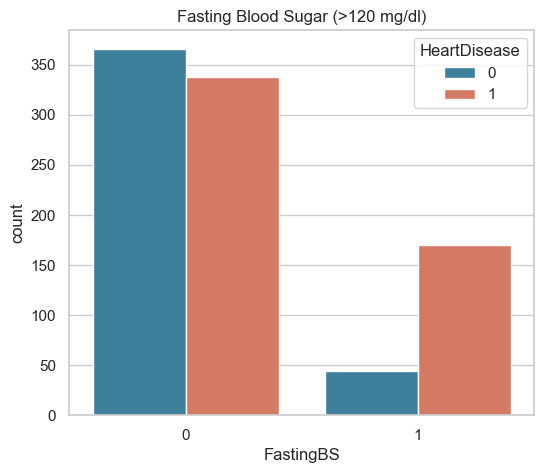

In [88]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='FastingBS', hue='HeartDisease', palette=palette)
plt.title('Fasting Blood Sugar (>120 mg/dl)')
plt.show()

C:\Users\Eng\AppData\Local\Temp\ipykernel_14412\701126697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RestingECG', palette=palette )
C:\Users\Eng\AppData\Local\Temp\ipykernel_14412\701126697.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x='RestingECG', palette=palette )


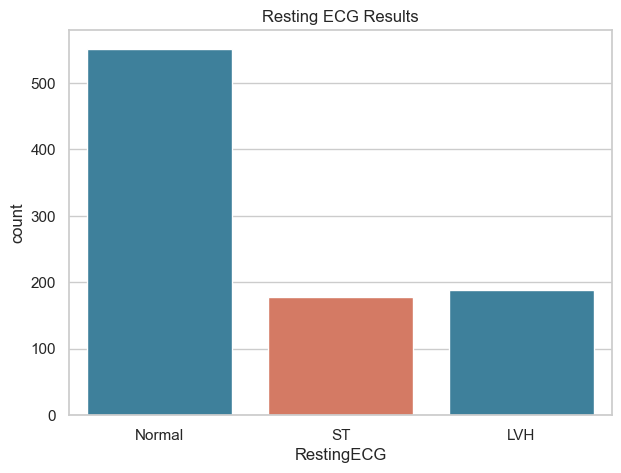

In [89]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='RestingECG', palette=palette )
plt.title('Resting ECG Results')
plt.show()

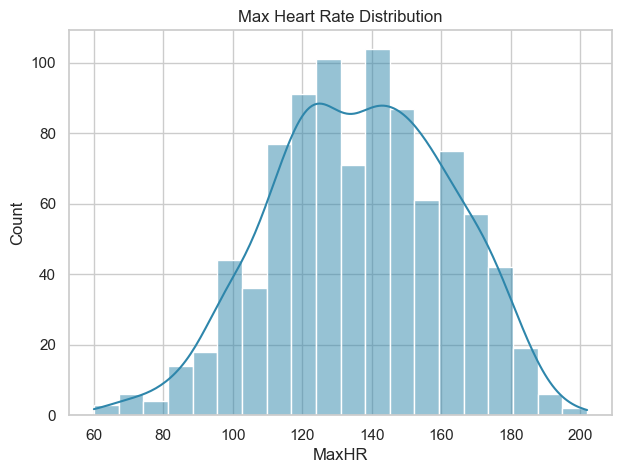

In [90]:
plt.figure(figsize=(7, 5))
sns.histplot(df['MaxHR'], kde=True, color=palette[0], bins=20)
plt.title('Max Heart Rate Distribution')
plt.show()

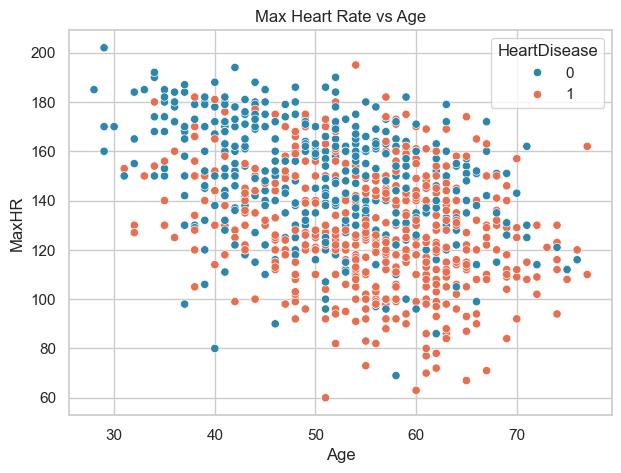

In [91]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Age', y='MaxHR', hue='HeartDisease', palette=palette)
plt.title('Max Heart Rate vs Age')
plt.show()

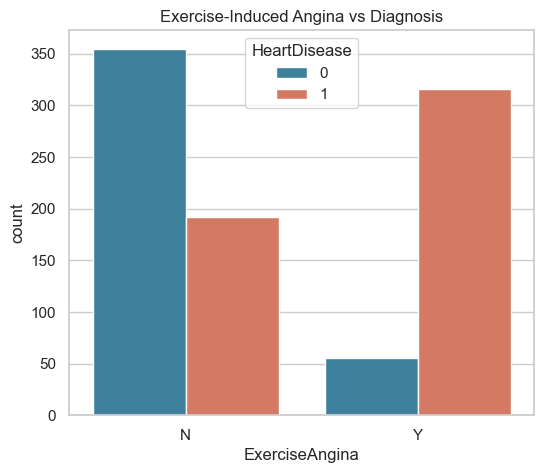

In [92]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='ExerciseAngina', hue='HeartDisease', palette=palette)
plt.title('Exercise-Induced Angina vs Diagnosis')
plt.show()

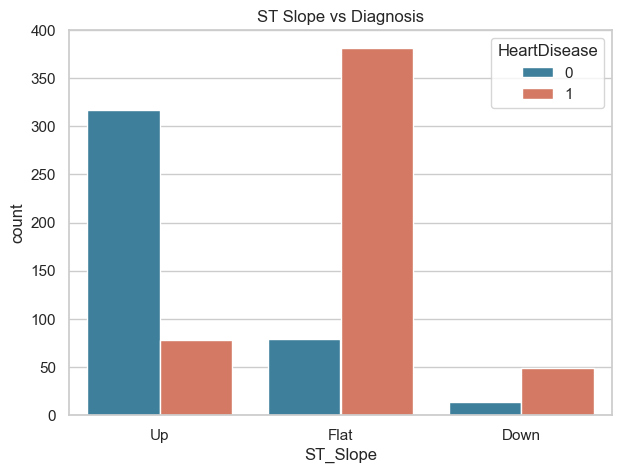

In [93]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', order=['Up','Flat','Down'], palette=palette)
plt.title('ST Slope vs Diagnosis')
plt.show()

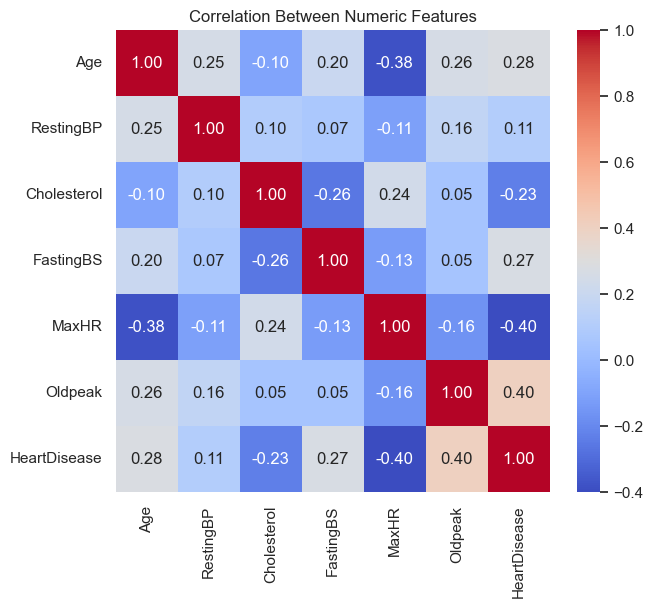

In [94]:
numeric_cols = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']

plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()

## 7. Data Preprocessing

In [95]:
X = df.drop(columns=['HeartDisease'], axis=1)
y = df['HeartDisease']

In [96]:
X_encoded = pd.get_dummies(X , drop_first=True).astype('int')

In [97]:
X_train , X_test , y_train , y_test = train_test_split(X_encoded , y , test_size=0.2 , stratify=y ,random_state=42)

In [98]:
X_train

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,63,139,217,1,128,1,1,1,0,0,0,1,1,1,0
486,55,110,214,1,180,0,1,1,0,0,0,1,0,0,1
117,59,130,338,1,130,1,0,0,0,0,0,1,1,1,0
361,47,160,0,0,124,0,1,0,0,0,1,0,1,1,0
296,50,145,0,1,139,0,1,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,51,135,160,0,150,2,1,0,1,0,1,0,0,1,0
201,46,120,230,0,150,0,1,0,1,0,1,0,0,0,1
462,59,122,233,0,117,1,1,0,0,0,1,0,1,0,0
252,61,125,292,0,115,0,1,0,0,0,0,1,1,0,1


## 8. Model 1 — Logistic Regression

In [99]:
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train , y_train)

c:\Users\Eng\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [100]:
y_pred_lr = model_lr.predict(X_test)

In [101]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

Confusion Matrix:
[[69 13]
 [ 7 95]]


## 9. Model 2 — Support Vector Machine (SVM)

In [102]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
svc_model = SVC(kernel='rbf' , random_state = 42)
svc_model.fit(X_train_scaled , y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [104]:
y_pred_svc = svc_model.predict(X_test_scaled)

In [105]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svc))
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88        82
           1       0.88      0.94      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184

SVM Confusion Matrix:
[[69 13]
 [ 6 96]]


## 10. Conclusion

Logistic Regression Accuracy: 0.8913043478260869
SVM Accuracy: 0.8967391304347826


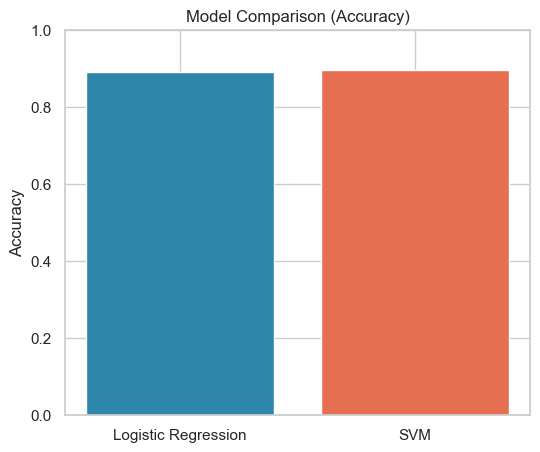

In [106]:
lr_acc  = accuracy_score(y_test, y_pred_lr)
svc_acc = accuracy_score(y_test, y_pred_svc)

print("Logistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svc_acc)


plt.figure(figsize=(6, 5))
plt.bar(['Logistic Regression', 'SVM'], [lr_acc, svc_acc],color=palette)
plt.title('Model Comparison (Accuracy)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()